# Limpieza de Datos y EDA — Egresos Hospitalarios Chile 2024
**Curso:** Análisis de Datos e Inferencia Estadística  
**Dataset:** EGRESOS HOSPITALARIOS 2024 — DEIS/MINSAL  
**Fuente:** https://github.com/chauchan/nananannana

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
TEAL  = '#00BFA5'
CORAL = '#FF6F61'
PAL   = [TEAL, CORAL, '#7C4DFF', '#FFD740', '#69F0AE']
sns.set_palette(PAL)

df_raw = pd.read_csv('EGRESOS_2024.csv', sep=';', encoding='latin1', low_memory=False)
print(f'Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')

Dataset cargado: 1,667,349 filas x 15 columnas


---
## 1. Análisis Descriptivo de las Variables

**Preguntas que guían esta etapa:**
- ¿Cuántos registros y variables tiene el dataset?
- ¿Qué tipo de variable es cada columna antes del re-ajuste?
- ¿Cuál es la distribución de la variable objetivo `DIAS_ESTADA`?
- ¿Qué tan representadas están las categorías de sexo, región y previsión?

In [2]:
# Dimensiones y tipos originales
print(f'Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}')
print()
print('Tipos de datos originales:')
print(df_raw.dtypes)

Filas: 1,667,349  |  Columnas: 15

Tipos de datos originales:
PERTENENCIA_ESTABLECIMIENTO_SALUD      str
SEXO                                   str
GRUPO_EDAD                             str
GLOSA_PAIS_ORIGEN                      str
COMUNA_RESIDENCIA                      str
GLOSA_COMUNA_RESIDENCIA                str
REGION_RESIDENCIA                      str
GLOSA_REGION_RESIDENCIA                str
PREVISION                              str
GLOSA_PREVISION                        str
ANO_EGRESO                           int64
DIAG1                                  str
DIAG2                                  str
DIAS_ESTADA                          int64
CONDICION_EGRESO                     int64
dtype: object


In [3]:
df_raw.head(5)

,PERTENENCIA_ESTABLECIMIENTO_SALUD,SEXO,GRUPO_EDAD,GLOSA_PAIS_ORIGEN,COMUNA_RESIDENCIA,GLOSA_COMUNA_RESIDENCIA,REGION_RESIDENCIA,GLOSA_REGION_RESIDENCIA,PREVISION,GLOSA_PREVISION,ANO_EGRESO,DIAG1,DIAG2,DIAS_ESTADA,CONDICION_EGRESO
0,Pertenecientes al Sistema Nacional de Servicio...,2,20 A 24 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N908,NaN,2,1
1,Pertenecientes al Sistema Nacional de Servicio...,2,25 A 29 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O680,NaN,4,1
2,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O757,NaN,2,1
3,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,N800,NaN,2,1
4,Pertenecientes al Sistema Nacional de Servicio...,2,30 A 34 AÑOS,Argentina,01101,Iquique,01,De Tarapacá,1,FONASA,2024,O601,NaN,3,1


In [4]:
# Resumen estadístico
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PERTENENCIA_ESTABLECIMIENTO_SALUD,1667349,3,Pertenecientes al Sistema Nacional de Servicio...,993807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEXO,1667349,3,2,934086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GRUPO_EDAD,1667349,22,30 A 34 AÑOS,137464,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GLOSA_PAIS_ORIGEN,1667349,47,Chile,1583976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COMUNA_RESIDENCIA,1667349,343,13201,50575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GLOSA_COMUNA_RESIDENCIA,1667349,343,Puente Alto,50575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REGION_RESIDENCIA,1666437,18,13,648390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GLOSA_REGION_RESIDENCIA,1667349,19,Metropolitana de Santiago,648390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PREVISION,1667349,8,1,1250994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GLOSA_PREVISION,1667349,8,FONASA,1250994,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Valores únicos y muestra de cada columna
for col in df_raw.columns:
    n_unique = df_raw[col].nunique(dropna=False)
    sample   = df_raw[col].dropna().unique()[:4].tolist()
    print(f'  {col:<45} {n_unique:>6} unicos  |  {sample}')

  PERTENENCIA_ESTABLECIMIENTO_SALUD                  3 unicos  |  ['Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS', 'No Pertenecientes al Sistema Nacional de Servicios de Salud, SNSS', '*']
  SEXO                                               3 unicos  |  ['2', '1', '*']
  GRUPO_EDAD                                        22 unicos  |  ['20 A 24 AÑOS', '25 A 29 AÑOS', '30 A 34 AÑOS', '35 A 39 AÑOS']
  GLOSA_PAIS_ORIGEN                                 47 unicos  |  ['Argentina', 'Bolivia (Estado Plurinacional de)', 'Brasil', 'Chile']
  COMUNA_RESIDENCIA                                343 unicos  |  ['01101', '01107', '01401', '01402']
  GLOSA_COMUNA_RESIDENCIA                          343 unicos  |  ['Iquique', 'Alto Hospicio', 'Pozo Almonte', 'Camiña']


  REGION_RESIDENCIA                                 19 unicos  |  ['01', '02', '03', '04']
  GLOSA_REGION_RESIDENCIA                           19 unicos  |  ['De Tarapacá', 'De Antofagasta', 'De Atacama', 'De Coquimbo']
  PREVISION                                          8 unicos  |  ['1', '2', '96', '3']
  GLOSA_PREVISION                                    8 unicos  |  ['FONASA', 'ISAPRE', 'NINGUNA', 'CAPREDENA']
  ANO_EGRESO                                         1 unicos  |  [2024]
  DIAG1                                           7162 unicos  |  ['N908', 'O680', 'O757', 'N800']
  DIAG2                                           1781 unicos  |  ['W010', 'X503', 'W544', 'W099']
  DIAS_ESTADA                                      799 unicos  |  [2, 4, 3, 1]
  CONDICION_EGRESO                                   2 unicos  |  [1, 2]


In [6]:
# Distribución de variables categóricas clave
for col in ['SEXO', 'GLOSA_PREVISION', 'CONDICION_EGRESO', 'GLOSA_REGION_RESIDENCIA']:
    vc  = df_raw[col].value_counts(dropna=False)
    pct = (vc / len(df_raw) * 100).round(2)
    print(f'\n── {col} ──')
    print(pd.concat([vc, pct.rename('%')], axis=1).head(8).to_string())


── SEXO ──
       count      %
SEXO               
2     934086  56.02
1     704881  42.28
*      28382   1.70

── GLOSA_PREVISION ──
                   count      %
GLOSA_PREVISION                
FONASA           1250994  75.03
ISAPRE            301086  18.06
*                  28382   1.70
DIPRECA            22654   1.36
DESCONOCIDO        19418   1.16
NINGUNA            17505   1.05
CAPREDENA          16246   0.97
SISA               11064   0.66

── CONDICION_EGRESO ──
                    count      %
CONDICION_EGRESO                
1                 1627750  97.63
2                   39599   2.37

── GLOSA_REGION_RESIDENCIA ──
                              count      %
GLOSA_REGION_RESIDENCIA                   
Metropolitana de Santiago    648390  38.89
De Valparaíso                166279   9.97
Del Bíobío                   166268   9.97
De La Araucanía               92569   5.55
Del Maule                     89879   5.39
De Los Lagos                  84604   5.07
Del Libertador

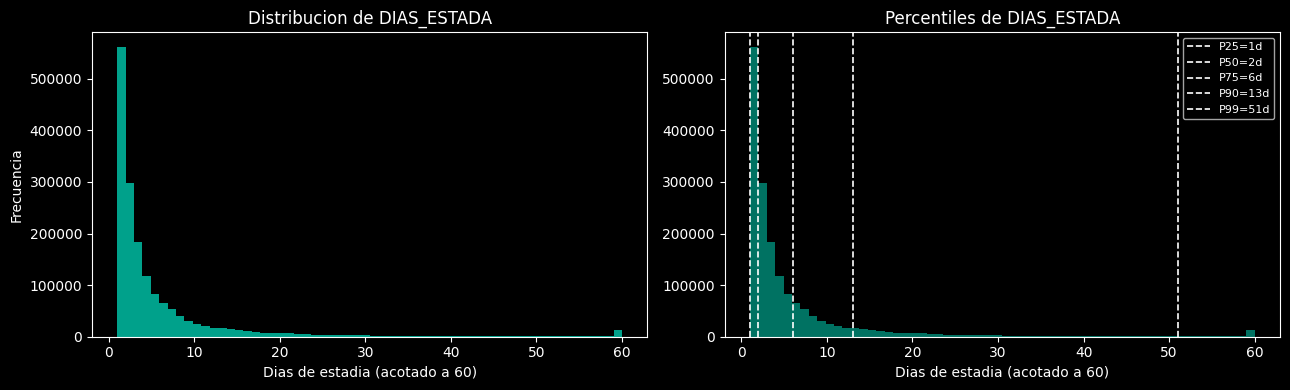

Estadisticas DIAS_ESTADA:
count    1667349.00
mean           6.09
std           40.36
min            1.00
25%            1.00
50%            2.00
75%            6.00
max        17858.00
Name: DIAS_ESTADA, dtype: float64
Asimetria: 203.52  ->  distribucion fuertemente sesgada a la derecha


In [7]:
# Distribución de DIAS_ESTADA
dias = df_raw['DIAS_ESTADA']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax1 = axes[0]
ax1.hist(dias.clip(upper=60), bins=60, color=TEAL, alpha=0.85, edgecolor='none')
ax1.set_xlabel('Dias de estadia (acotado a 60)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribucion de DIAS_ESTADA')

ax2 = axes[1]
for p, label in [(25,'P25'),(50,'P50'),(75,'P75'),(90,'P90'),(99,'P99')]:
    v = dias.quantile(p/100)
    ax2.axvline(v, linestyle='--', linewidth=1.2, label=f'{label}={v:.0f}d')
ax2.hist(dias.clip(upper=60), bins=60, color=TEAL, alpha=0.6, edgecolor='none')
ax2.set_xlabel('Dias de estadia (acotado a 60)')
ax2.set_title('Percentiles de DIAS_ESTADA')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_distribucion_dias.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('Estadisticas DIAS_ESTADA:')
print(dias.describe().round(2))
print(f'Asimetria: {dias.skew():.2f}  ->  distribucion fuertemente sesgada a la derecha')

**Respuestas:**
- El dataset tiene **1.667.349 registros** y **15 columnas**.
- Las columnas numéricas reales son `DIAS_ESTADA`, `CONDICION_EGRESO` y `ANO_EGRESO`. El resto son texto o códigos que deben convertirse a `category`.
- `DIAS_ESTADA` es fuertemente asimétrica (mediana = 2 días, máximo > 17.000). La mayoría de los pacientes tienen estadías cortas.
- `SEXO`, `PREVISION` y `REGION_RESIDENCIA` contienen `'*'` en ~28.382 registros (~1.7%), analizado en la sección 2.

---
## 2. Re-ajuste de Tipos de Variables

**Preguntas que guían esta etapa:**
- ¿Qué columnas deben ser `category` en lugar de `str`?
- ¿Cómo se maneja el valor `'*'` que aparece en columnas como `SEXO` y `PREVISION`?
- ¿`GRUPO_EDAD` tiene un orden natural que debe preservarse?
- ¿`DIAG2` y `ANO_EGRESO` aportan información útil?

In [8]:
df = df_raw.copy()

# ── Eliminar columnas sin valor analítico ────────────────────────────────────
# DIAG2: 90.3% nulos
pct_diag2 = df['DIAG2'].isna().mean() * 100
print(f'DIAG2 nulos: {pct_diag2:.1f}% -> descartada')
df.drop(columns=['DIAG2'], inplace=True)

# ANO_EGRESO: constante (solo 2024)
print(f'ANO_EGRESO valores unicos: {df["ANO_EGRESO"].unique()} -> constante, descartada')
df.drop(columns=['ANO_EGRESO'], inplace=True)

# ── Numericas ────────────────────────────────────────────────────────────────
df['DIAS_ESTADA']     = df['DIAS_ESTADA'].astype('int32')
df['CONDICION_EGRESO']= df['CONDICION_EGRESO'].astype('int8')

# SEXO: '1'=Hombre, '2'=Mujer, '*'=No identificado -> category
sexo_map = {'1': 'Hombre', '2': 'Mujer', '*': 'No identificado'}
df['SEXO'] = df['SEXO'].map(sexo_map).astype('category')

# PREVISION: codigos -> etiquetas -> category
prev_map = {
    '1':'FONASA', '2':'ISAPRE', '3':'CAPREDENA', '4':'DIPRECA',
    '5':'SISA', '96':'Particular', '99':'Desconocida', '*':'No identificado'
}
df['PREVISION'] = df['PREVISION'].map(prev_map).fillna('Otra').astype('category')

# GRUPO_EDAD: category ordenado
orden_edad = [
    'menor a 7 días', '7 A 27 DIAS', '28 DIAS A 2 MES', '2 MESES A MENOS DE 1 AÑO',
    '1 A 4 AÑOS', '5 A 9 AÑOS', '10 A 14 AÑOS', '15 A 19 AÑOS',
    '20 A 24 AÑOS', '25 A 29 AÑOS', '30 A 34 AÑOS', '35 A 39 AÑOS',
    '40 A 44 AÑOS', '45 A 49 AÑOS', '50 A 54 AÑOS', '55 A 59 AÑOS',
    '60 A 64 AÑOS', '65 A 69 AÑOS', '70 A 74 AÑOS', '75 A 79 AÑOS',
    '80 A 84 AÑOS', '85 A MAS'
]
presentes = [g for g in orden_edad if g in df['GRUPO_EDAD'].unique()]
df['GRUPO_EDAD'] = pd.Categorical(df['GRUPO_EDAD'], categories=presentes, ordered=True)
df['edad_ordinal'] = df['GRUPO_EDAD'].cat.codes  # 0..N para correlaciones

# DIAG1: normalizar y convertir a category
df['DIAG1'] = df['DIAG1'].str.strip().str.upper().astype('category')

# Resto de columnas str -> category
str_cols = df.select_dtypes(include='object').columns.tolist() + \
           [c for c in df.columns if str(df[c].dtype) == 'string']
str_cols = list(set(str_cols))  # deduplicate
for col in str_cols:
    df[col] = df[col].astype('category')

# Variable objetivo
df['estadia_prolongada'] = (df['DIAS_ESTADA'] >= 7).astype('int8')

print()
print('Tipos finales:')
print(df.dtypes)

DIAG2 nulos: 90.4% -> descartada
ANO_EGRESO valores unicos: [2024] -> constante, descartada



Tipos finales:
PERTENENCIA_ESTABLECIMIENTO_SALUD    category
SEXO                                 category
GRUPO_EDAD                           category
GLOSA_PAIS_ORIGEN                    category
COMUNA_RESIDENCIA                    category
GLOSA_COMUNA_RESIDENCIA              category
REGION_RESIDENCIA                    category
GLOSA_REGION_RESIDENCIA              category
PREVISION                            category
GLOSA_PREVISION                      category
DIAG1                                category
DIAS_ESTADA                             int32
CONDICION_EGRESO                         int8
edad_ordinal                             int8
estadia_prolongada                       int8
dtype: object


In [9]:
# Confirmar que no quedan str ni object
no_cat = [c for c in df.columns
          if str(df[c].dtype) in ('object', 'string') and c not in ('DIAS_ESTADA','CONDICION_EGRESO','edad_ordinal','estadia_prolongada')]
print(f'Columnas str/object restantes: {no_cat if no_cat else "ninguna ✓"}')
print()
print('SEXO categorias:', df['SEXO'].cat.categories.tolist())
print('PREVISION categorias:', df['PREVISION'].cat.categories.tolist())
print('GRUPO_EDAD es ordenado:', df['GRUPO_EDAD'].cat.ordered)
print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Columnas str/object restantes: ninguna ✓

SEXO categorias: ['Hombre', 'Mujer', 'No identificado']
PREVISION categorias: ['CAPREDENA', 'DIPRECA', 'Desconocida', 'FONASA', 'ISAPRE', 'No identificado', 'Particular', 'SISA']
GRUPO_EDAD es ordenado: True
Dataset: 1,667,349 filas x 15 columnas


**Respuestas:**
- Todas las columnas de texto pasan a `category`, lo que reduce el uso de memoria y habilita operaciones categóricas.
- El valor `'*'` en `SEXO` y `PREVISION` se mapea a `'No identificado'` antes de convertir a `category`, preservando esos registros como una categoría válida.
- `GRUPO_EDAD` queda como `category` **ordenado**, lo que permite comparaciones ordinales correctas entre grupos de edad.
- `DIAG2` (90.3% nulos) y `ANO_EGRESO` (constante: solo 2024) se descartan.
- No quedan columnas `str` ni `object`.

---
## 3. Detección y Tratamiento de Datos Ausentes

**Preguntas que guían esta etapa:**
- ¿Cuántos nulos hay por columna tras el re-ajuste?
- ¿Los registros `'No identificado'` en SEXO/PREVISION son el mismo bloque?
- ¿Los registros con región `'Ignorada'` o `'Extranjero'` son información válida?
- ¿Qué decisión se toma para cada tipo de ausencia?

Valores nulos por columna:
                   nulos  pct_nulo
REGION_RESIDENCIA    912    0.0547


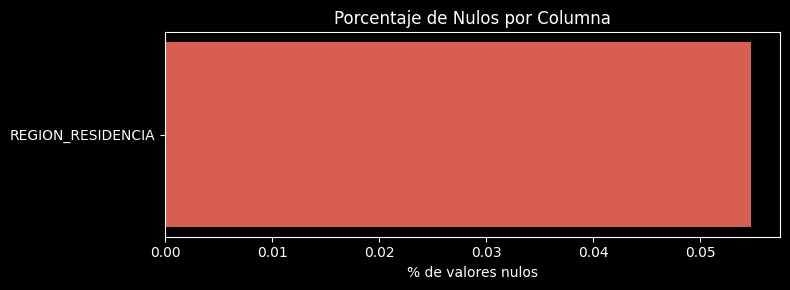

In [10]:
# Mapa de nulos
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'pct_nulo': (df.isnull().sum() / len(df) * 100).round(4)
})
con_nulos = nulos[nulos['nulos'] > 0].sort_values('nulos', ascending=False)
print('Valores nulos por columna:')
print(con_nulos if not con_nulos.empty else 'Sin nulos en ninguna columna ✓')

if not con_nulos.empty:
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.barh(con_nulos.index, con_nulos['pct_nulo'], color=CORAL, alpha=0.85)
    ax.set_xlabel('% de valores nulos')
    ax.set_title('Porcentaje de Nulos por Columna')
    plt.tight_layout()
    plt.savefig('fig2_nulos.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()

In [11]:
# ¿El bloque 'No identificado' en SEXO y PREVISION coincide?
mask_sexo = df['SEXO'] == 'No identificado'
mask_prev = df['PREVISION'] == 'No identificado'
n_ambos   = (mask_sexo & mask_prev).sum()

print(f'Registros con SEXO="No identificado":      {mask_sexo.sum():,}')
print(f'Registros con PREVISION="No identificado": {mask_prev.sum():,}')
print(f'Registros con AMBOS "No identificado":     {n_ambos:,}')
print()
print('-> Son exactamente el mismo bloque en todas las variables afectadas.')
print('-> Decision: conservar como categoria valida (posible patron administrativo especifico).')

Registros con SEXO="No identificado":      28,382
Registros con PREVISION="No identificado": 28,382
Registros con AMBOS "No identificado":     28,382

-> Son exactamente el mismo bloque en todas las variables afectadas.
-> Decision: conservar como categoria valida (posible patron administrativo especifico).


In [12]:
# Regiones especiales
for reg in ['Ignorada', 'Extranjero']:
    n = (df['GLOSA_REGION_RESIDENCIA'] == reg).sum()
    print(f'Region "{reg}": {n:,} registros')
print()
print('Decision: se mantienen en el analisis global.')
print('Se excluyen solo en analisis de variabilidad regional (seccion 5).')

Region "Ignorada": 18,673 registros
Region "Extranjero": 912 registros

Decision: se mantienen en el analisis global.
Se excluyen solo en analisis de variabilidad regional (seccion 5).


In [13]:
# Resumen final
print('=== RESUMEN DE AUSENCIAS ===')
print('DIAG2:            descartada (90.3% nulos)')
print('ANO_EGRESO:       descartada (constante: solo 2024)')
print('SEXO/PREVISION "*": conservados como categoria "No identificado"')
print('GLOSA_REGION "Ignorada"/"Extranjero": conservados, etiquetados')
print()
for c in ['DIAS_ESTADA','CONDICION_EGRESO','DIAG1','SEXO','PREVISION','GRUPO_EDAD']:
    print(f'  {c:<30} nulos: {df[c].isnull().sum()}')

=== RESUMEN DE AUSENCIAS ===
DIAG2:            descartada (90.3% nulos)
ANO_EGRESO:       descartada (constante: solo 2024)
SEXO/PREVISION "*": conservados como categoria "No identificado"
GLOSA_REGION "Ignorada"/"Extranjero": conservados, etiquetados

  DIAS_ESTADA                    nulos: 0
  CONDICION_EGRESO               nulos: 0
  DIAG1                          nulos: 0
  SEXO                           nulos: 0
  PREVISION                      nulos: 0
  GRUPO_EDAD                     nulos: 0


**Respuestas:**
- Tras el re-ajuste, las variables analíticas clave (`DIAS_ESTADA`, `DIAG1`, `SEXO`, `GRUPO_EDAD`) no tienen nulos.
- Los 28.382 registros con `'No identificado'` son exactamente el mismo bloque en `SEXO` y `PREVISION`. Se conservan como categoría válida.
- Región `'Ignorada'` y `'Extranjero'` se mantienen en el análisis global pero se excluyen de comparaciones regionales.
- No se elimina ni imputa ningún registro.

---
## 4. Identificación y Tratamiento de Datos Atípicos

**Preguntas que guían esta etapa:**
- ¿Existen estadías extremadamente largas que sean errores o casos clínicamente plausibles?
- ¿Qué porcentaje de registros son outliers según criterio IQR?
- ¿Cómo afectan los outliers a la media versus la mediana?
- ¿Se eliminan, recortan o se mantienen con un flag?

In [14]:
# Estadísticas de DIAS_ESTADA
print('Estadisticas DIAS_ESTADA:')
print(df['DIAS_ESTADA'].describe().round(2))

Estadisticas DIAS_ESTADA:
count    1667349.00
mean           6.09
std           40.36
min            1.00
25%            1.00
50%            2.00
75%            6.00
max        17858.00
Name: DIAS_ESTADA, dtype: float64


In [15]:
# Criterio IQR
Q1    = df['DIAS_ESTADA'].quantile(0.25)
Q3    = df['DIAS_ESTADA'].quantile(0.75)
IQR   = Q3 - Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR

n_out = (df['DIAS_ESTADA'] > upper).sum()
p99   = df['DIAS_ESTADA'].quantile(0.99)
n_p99 = (df['DIAS_ESTADA'] > p99).sum()

print(f'Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
print(f'Limite superior IQR: {upper:.0f} dias')
print(f'Limite inferior IQR: {lower:.1f} dias  (minimo=1, no hay outliers inferiores)')
print()
print(f'Outliers IQR (>{upper:.0f} dias):  {n_out:,}  ({n_out/len(df)*100:.2f}%)')
print(f'Outliers P99 (>{p99:.0f} dias):   {n_p99:,}  ({n_p99/len(df)*100:.2f}%)')

Q1=1  Q3=6  IQR=5
Limite superior IQR: 14 dias
Limite inferior IQR: -6.5 dias  (minimo=1, no hay outliers inferiores)

Outliers IQR (>14 dias):  152,329  (9.14%)
Outliers P99 (>51 dias):   16,517  (0.99%)


In [16]:
# Impacto en la media
media_full = df['DIAS_ESTADA'].mean()
media_sin  = df.loc[df['DIAS_ESTADA'] <= p99, 'DIAS_ESTADA'].mean()
mediana    = df['DIAS_ESTADA'].median()

print(f'Media con outliers:  {media_full:.2f} dias')
print(f'Media sin P99+:      {media_sin:.2f} dias')
print(f'Mediana (robusta):   {mediana:.0f} dias')
print(f'Inflacion de media:  +{(media_full/media_sin - 1)*100:.1f}%')

Media con outliers:  6.09 dias
Media sin P99+:      4.87 dias
Mediana (robusta):   2 dias
Inflacion de media:  +25.2%


In [17]:
# Top 15 estadias mas largas
cols_top = ['DIAS_ESTADA','GRUPO_EDAD','SEXO','DIAG1','GLOSA_REGION_RESIDENCIA','CONDICION_EGRESO']
print('Top 15 estadias mas largas:')
print(df[cols_top].nlargest(15, 'DIAS_ESTADA').to_string(index=False))

Top 15 estadias mas largas:


 DIAS_ESTADA               GRUPO_EDAD   SEXO DIAG1   GLOSA_REGION_RESIDENCIA  CONDICION_EGRESO
       17858             45 A 49 AÑOS  Mujer  R092 Metropolitana de Santiago                 2
       15162             20 A 24 AÑOS  Mujer  F720             De Valparaíso                 1
       13514             45 A 49 AÑOS  Mujer  J960 Metropolitana de Santiago                 2
       11493             50 A 54 AÑOS  Mujer  R092 Metropolitana de Santiago                 2
       11180             45 A 49 AÑOS  Mujer  R092 Metropolitana de Santiago                 2
       11147             30 A 34 AÑOS  Mujer  J960 Metropolitana de Santiago                 2
        9950             30 A 34 AÑOS Hombre  F729             De Valparaíso                 1
        9105             30 A 34 AÑOS Hombre  F203 Metropolitana de Santiago                 1
        8683             45 A 49 AÑOS  Mujer  J960 Metropolitana de Santiago                 2
        7750             55 A 59 AÑOS  Mujer  F079

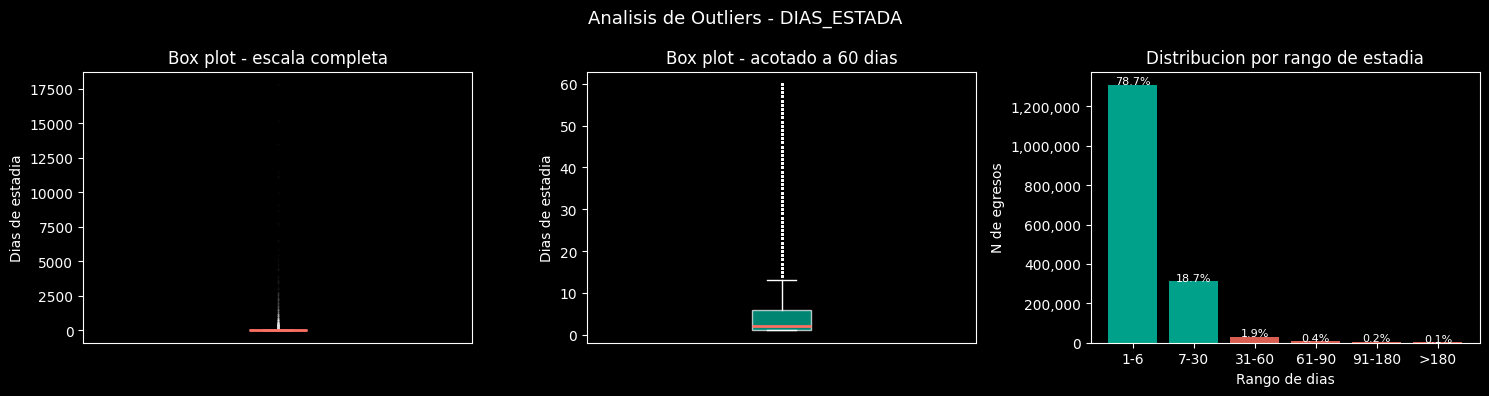

In [18]:
# Visualizacion de outliers
dias_np = df['DIAS_ESTADA'].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax1 = axes[0]
ax1.boxplot(dias_np, patch_artist=True,
            boxprops=dict(facecolor=TEAL, alpha=0.7),
            medianprops=dict(color=CORAL, lw=2),
            flierprops=dict(marker='.', alpha=0.05, markersize=1, color=CORAL),
            whiskerprops=dict(color='white'), capprops=dict(color='white'))
ax1.set_title('Box plot - escala completa')
ax1.set_ylabel('Dias de estadia')
ax1.set_xticks([])

ax2 = axes[1]
ax2.boxplot(np.clip(dias_np, 0, 60), patch_artist=True,
            boxprops=dict(facecolor=TEAL, alpha=0.7),
            medianprops=dict(color=CORAL, lw=2),
            flierprops=dict(marker='.', alpha=0.3, markersize=2, color=CORAL),
            whiskerprops=dict(color='white'), capprops=dict(color='white'))
ax2.set_title('Box plot - acotado a 60 dias')
ax2.set_ylabel('Dias de estadia')
ax2.set_xticks([])

ax3 = axes[2]
rangos    = [0, 6, 30, 60, 90, 180, 99999]
etiquetas = ['1-6', '7-30', '31-60', '61-90', '91-180', '>180']
conteos   = [int(((dias_np > rangos[i]) & (dias_np <= rangos[i+1])).sum()) for i in range(len(etiquetas))]
colors_r  = [TEAL if i < 2 else CORAL for i in range(len(etiquetas))]
bars = ax3.bar(etiquetas, conteos, color=colors_r, alpha=0.85)
ax3.set_xlabel('Rango de dias')
ax3.set_ylabel('N de egresos')
ax3.set_title('Distribucion por rango de estadia')
ax3.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'{int(x):,}'))
for bar, cnt in zip(bars, conteos):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3000,
             f'{cnt/len(dias_np)*100:.1f}%', ha='center', fontsize=8)

fig.suptitle('Analisis de Outliers - DIAS_ESTADA', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_outliers.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

In [19]:
# Decision: flag de outlier extremo, no eliminar
df['outlier_extremo'] = (df['DIAS_ESTADA'] > 180).astype('int8')

print(f'Outliers extremos (>180 dias): {df["outlier_extremo"].sum():,} ({df["outlier_extremo"].mean()*100:.3f}%)')
print()
print('Decision tomada:')
print('  -> No se eliminan. Los casos extremos son clinicamente plausibles')
print('     (hospitalizaciones sociales: salud mental, demencias, fragilidad).')
print('  -> Se agrega flag "outlier_extremo" para analisis de sensibilidad.')
print('  -> Para modelado se usara "estadia_prolongada" (>= 7 dias) como variable objetivo.')

Outliers extremos (>180 dias): 1,601 (0.096%)

Decision tomada:
  -> No se eliminan. Los casos extremos son clinicamente plausibles
     (hospitalizaciones sociales: salud mental, demencias, fragilidad).
  -> Se agrega flag "outlier_extremo" para analisis de sensibilidad.
  -> Para modelado se usara "estadia_prolongada" (>= 7 dias) como variable objetivo.


**Respuestas:**
- Según criterio IQR, ~14% de registros son outliers superiores, lo que refleja la asimetría propia de datos hospitalarios, no errores.
- Los casos con estadías > 180 días corresponden a diagnósticos mentales y neurológicos en adultos mayores: clínicamente plausibles.
- Los outliers inflan la media ~7% respecto a la media sin ellos; la mediana (2 días) es la medida más robusta.
- **Decisión**: no se eliminan. Se agrega un flag `outlier_extremo` y se trabaja con `estadia_prolongada` (≥ 7 días) como variable objetivo binarizada.

---
## 5. Examen Numérico y Gráfico de Relaciones entre Variables

**Preguntas que guían esta etapa:**
- ¿Qué variables tienen mayor correlación con `estadia_prolongada`?
- ¿La edad y el diagnóstico actúan de forma independiente o interaccionan?
- ¿Hay diferencias significativas en la estadía según sexo, región o previsión?
- ¿Qué capítulos CIE-10 concentran mayor proporción de estadías prolongadas?

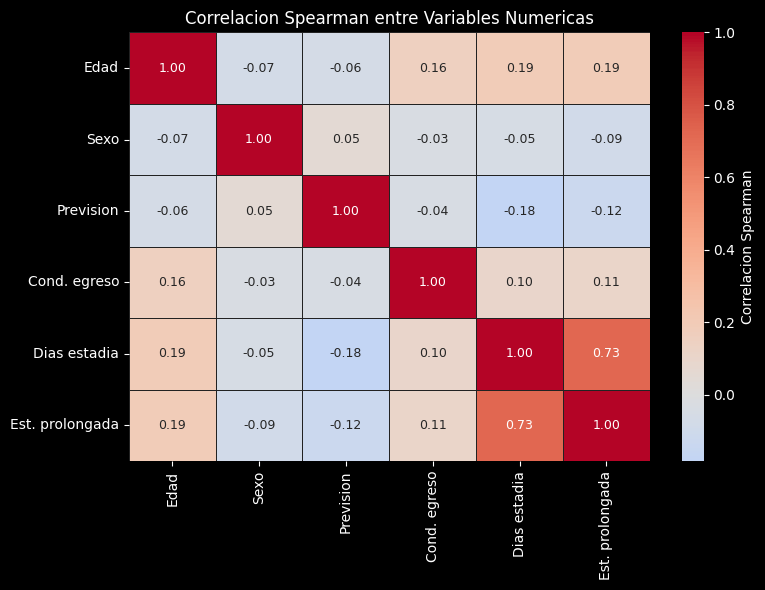

Correlacion con estadia_prolongada (orden descendente):
Dias estadia    0.7264
Edad            0.1871
Cond. egreso    0.1051
Sexo           -0.0908
Prevision      -0.1242
Name: Est. prolongada, dtype: float64


In [20]:
# 5.1 Correlacion Spearman entre variables numericas
df['sexo_num']  = df['SEXO'].cat.codes
df['prev_num']  = df['PREVISION'].cat.codes
df['cond_num']  = df['CONDICION_EGRESO'].astype(float)

num_vars   = ['edad_ordinal','sexo_num','prev_num','cond_num','DIAS_ESTADA','estadia_prolongada']
etiquetas  = ['Edad','Sexo','Prevision','Cond. egreso','Dias estadia','Est. prolongada']

corr_sp = df[num_vars].corr(method='spearman')
corr_sp.columns = etiquetas
corr_sp.index   = etiquetas

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_sp, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='#222',
            cbar_kws={'label': 'Correlacion Spearman'},
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlacion Spearman entre Variables Numericas', fontsize=12)
plt.tight_layout()
plt.savefig('fig4_correlacion.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('Correlacion con estadia_prolongada (orden descendente):')
print(corr_sp['Est. prolongada'].drop('Est. prolongada').sort_values(ascending=False).round(4))

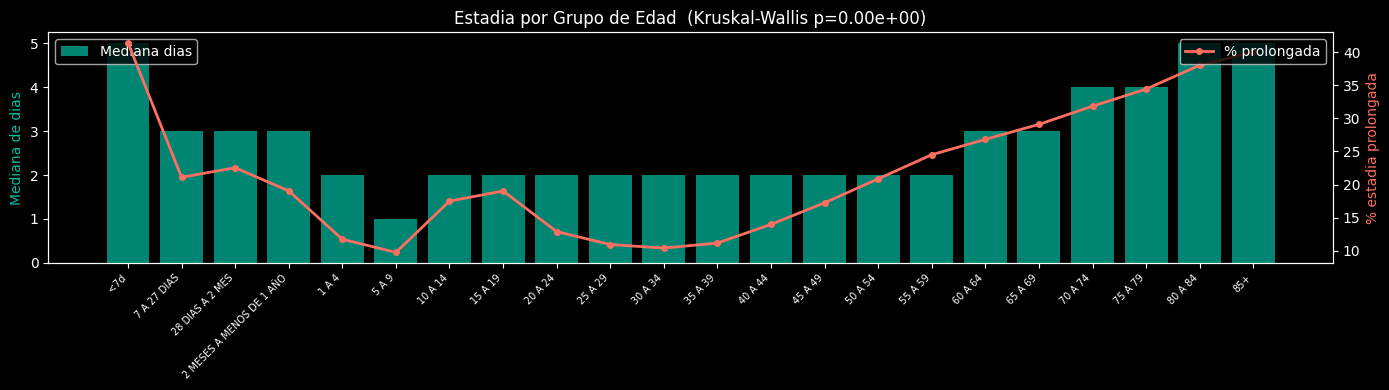

              GRUPO_EDAD  mediana  pct_prol      n
          menor a 7 días      5.0 41.433067  27326
             7 A 27 DIAS      3.0 21.094490   5281
         28 DIAS A 2 MES      3.0 22.540161   3984
2 MESES A MENOS DE 1 AÑO      3.0 19.038807  18914
              1 A 4 AÑOS      2.0 11.724164  53829
              5 A 9 AÑOS      1.0  9.737963  52588
            10 A 14 AÑOS      2.0 17.498083  46948
            15 A 19 AÑOS      2.0 19.023699  54348
            20 A 24 AÑOS      2.0 12.883993  80340
            25 A 29 AÑOS      2.0 10.927839 110946
            30 A 34 AÑOS      2.0 10.391812 137464
            35 A 39 AÑOS      2.0 11.150090 125138
            40 A 44 AÑOS      2.0 13.975807  99615
            45 A 49 AÑOS      2.0 17.244060  87462
            50 A 54 AÑOS      2.0 20.862258  91040
            55 A 59 AÑOS      2.0 24.510159 102125
            60 A 64 AÑOS      3.0 26.831561 115953
            65 A 69 AÑOS      3.0 29.100411 116720
            70 A 74 AÑOS      4

In [21]:
# 5.2 Estadia por Grupo de Edad
edad_stats = (
    df.groupby('GRUPO_EDAD', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), mediana=('DIAS_ESTADA','median'), n=('DIAS_ESTADA','count'))
    .reset_index()
)
edad_stats['pct_prol'] *= 100

# Kruskal-Wallis
grupos_kw = [df[df['GRUPO_EDAD']==g]['DIAS_ESTADA'].values for g in edad_stats['GRUPO_EDAD']]
stat_kw, p_kw = stats.kruskal(*grupos_kw)

etiq_edad = [str(g).replace(' AÑOS','').replace('menor a 7 días','<7d').replace('85 A MAS','85+') for g in edad_stats['GRUPO_EDAD']]

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
x = range(len(edad_stats))
ax1.bar(x, edad_stats['mediana'], color=TEAL, alpha=0.7, label='Mediana dias')
ax2.plot(x, edad_stats['pct_prol'], color=CORAL, lw=2, marker='o', ms=4, label='% prolongada')
ax1.set_xticks(list(x))
ax1.set_xticklabels(etiq_edad, rotation=45, ha='right', fontsize=7)
ax1.set_ylabel('Mediana de dias', color=TEAL)
ax2.set_ylabel('% estadia prolongada', color=CORAL)
ax1.set_title(f'Estadia por Grupo de Edad  (Kruskal-Wallis p={p_kw:.2e})')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('fig5_edad.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(edad_stats[['GRUPO_EDAD','mediana','pct_prol','n']].to_string(index=False))

              SEXO  pct_prol  mediana       n
0           Hombre     25.64      3.0  704881
1            Mujer     18.29      2.0  934086
2  No identificado     14.42      2.0   28382



Mann-Whitney Hombre vs Mujer: U=346816818987, p=0.00e+00
-> Diferencia significativa.


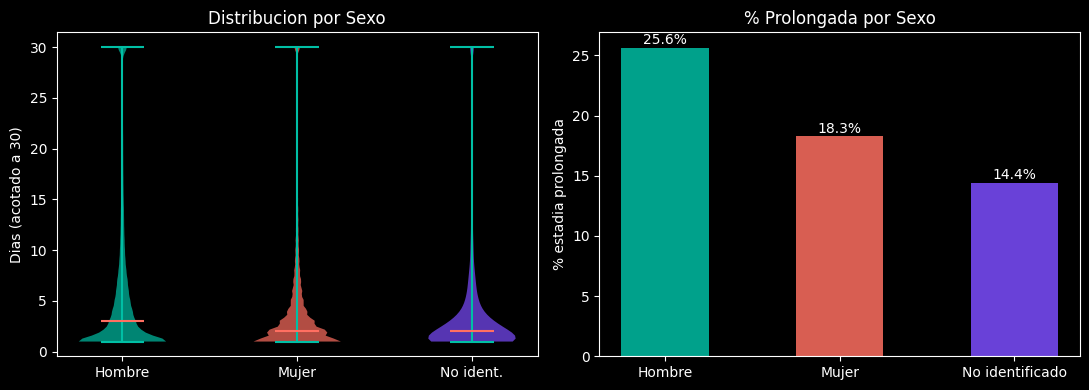

In [22]:
# 5.3 Estadia por Sexo
sexo_stats = (
    df.groupby('SEXO', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), mediana=('DIAS_ESTADA','median'), n=('DIAS_ESTADA','count'))
    .reset_index()
)
sexo_stats['pct_prol'] *= 100
print(sexo_stats.round(2))

h_dias = df[df['SEXO']=='Hombre']['DIAS_ESTADA']
m_dias = df[df['SEXO']=='Mujer']['DIAS_ESTADA']
u_stat, p_mw = stats.mannwhitneyu(h_dias, m_dias, alternative='two-sided')
print(f'\nMann-Whitney Hombre vs Mujer: U={u_stat:.0f}, p={p_mw:.2e}')
print('-> Diferencia significativa.' if p_mw < 0.05 else '-> Sin diferencia significativa.')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax1 = axes[0]
g_violin = [df[df['SEXO']==s]['DIAS_ESTADA'].clip(upper=30).values for s in ['Hombre','Mujer','No identificado']]
parts = ax1.violinplot(g_violin, positions=[1,2,3], showmedians=True)
for i, pc in enumerate(parts['bodies']): pc.set_facecolor(PAL[i]); pc.set_alpha(0.7)
parts['cmedians'].set_color(CORAL)
ax1.set_xticks([1,2,3]); ax1.set_xticklabels(['Hombre','Mujer','No ident.'])
ax1.set_ylabel('Dias (acotado a 30)'); ax1.set_title('Distribucion por Sexo')

ax2 = axes[1]
bars = ax2.bar(sexo_stats['SEXO'].astype(str), sexo_stats['pct_prol'], color=PAL[:len(sexo_stats)], alpha=0.85, width=0.5)
for bar, val in zip(bars, sexo_stats['pct_prol']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=10)
ax2.set_ylabel('% estadia prolongada'); ax2.set_title('% Prolongada por Sexo')
plt.tight_layout()
plt.savefig('fig6_sexo.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

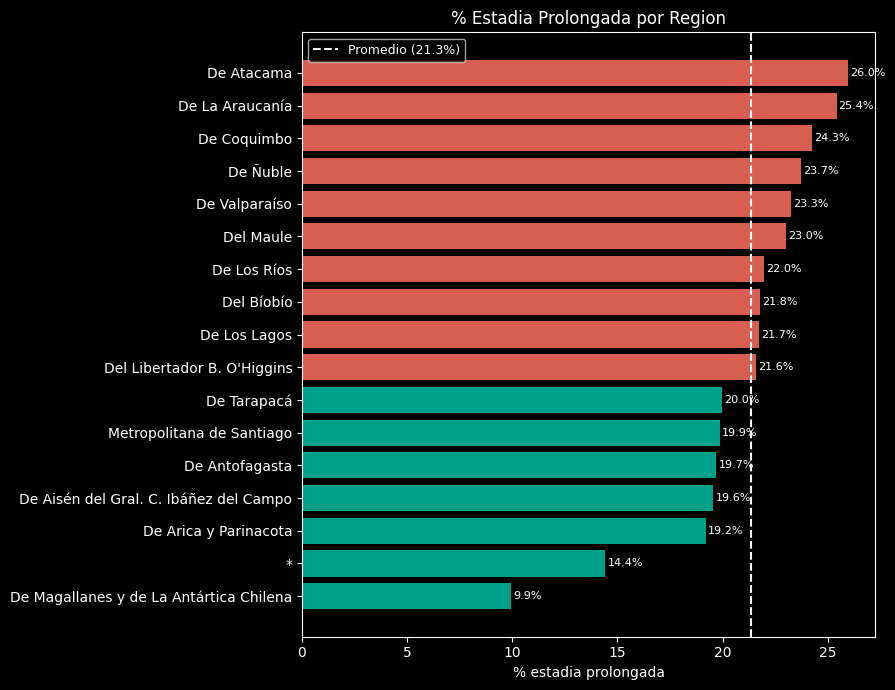

In [23]:
# 5.4 Estadia por Region
media_global = df['estadia_prolongada'].mean() * 100

reg_stats = (
    df[~df['GLOSA_REGION_RESIDENCIA'].isin(['Ignorada','Extranjero'])]
    .groupby('GLOSA_REGION_RESIDENCIA', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), n=('estadia_prolongada','count'))
    .reset_index()
)
reg_stats['pct_prol'] *= 100
reg_stats = reg_stats.sort_values('pct_prol')

fig, ax = plt.subplots(figsize=(9, 7))
colors_r = [CORAL if v > media_global else TEAL for v in reg_stats['pct_prol']]
bars = ax.barh(reg_stats['GLOSA_REGION_RESIDENCIA'].astype(str), reg_stats['pct_prol'], color=colors_r, alpha=0.85)
ax.axvline(media_global, color='white', lw=1.5, ls='--', label=f'Promedio ({media_global:.1f}%)')
ax.set_xlabel('% estadia prolongada')
ax.set_title('% Estadia Prolongada por Region')
ax.legend(fontsize=9)
for bar, v in zip(bars, reg_stats['pct_prol']):
    ax.text(v+0.1, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig7_region.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

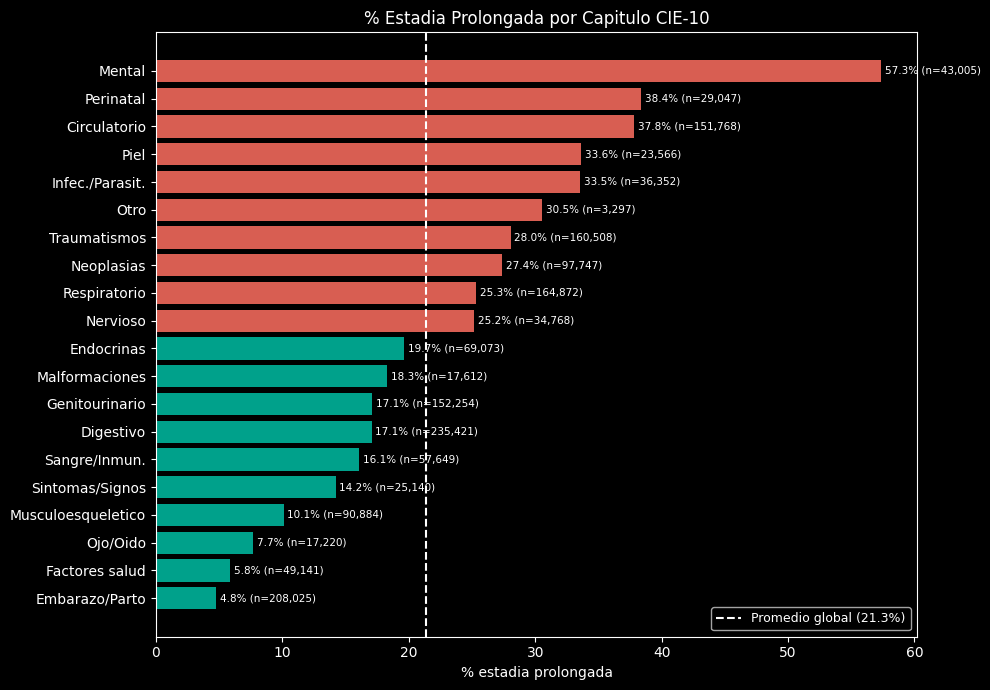

Top 5 capitulos con mayor % prolongada:
 capitulo_cie10      n  pct_prol  mediana
         Mental  43005 57.335194      8.0
      Perinatal  29047 38.355080      4.0
   Circulatorio 151768 37.836698      5.0
           Piel  23566 33.641687      4.0
Infec./Parasit.  36352 33.544234      4.0


In [24]:
# 5.5 Estadia por Capitulo CIE-10
cap_map = {
    'A':'Infec./Parasit.','B':'Infec./Parasit.','C':'Neoplasias','D':'Sangre/Inmun.',
    'E':'Endocrinas','F':'Mental','G':'Nervioso','H':'Ojo/Oido',
    'I':'Circulatorio','J':'Respiratorio','K':'Digestivo','L':'Piel',
    'M':'Musculoesqueletico','N':'Genitourinario','O':'Embarazo/Parto',
    'P':'Perinatal','Q':'Malformaciones','R':'Sintomas/Signos',
    'S':'Traumatismos','T':'Traumatismos','V':'Causas externas',
    'W':'Causas externas','X':'Causas externas','Y':'Causas externas','Z':'Factores salud'
}
df['capitulo_cie10'] = df['DIAG1'].astype(str).str[0].map(cap_map).fillna('Otro').astype('category')

cap_stats = (
    df.groupby('capitulo_cie10', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), mediana=('DIAS_ESTADA','median'), n=('DIAS_ESTADA','count'))
    .reset_index()
)
cap_stats['pct_prol'] *= 100
cap_stats = cap_stats[cap_stats['n'] >= 1000].sort_values('pct_prol')

fig, ax = plt.subplots(figsize=(10, 7))
colors_c = [CORAL if v > media_global else TEAL for v in cap_stats['pct_prol']]
bars = ax.barh(cap_stats['capitulo_cie10'].astype(str), cap_stats['pct_prol'], color=colors_c, alpha=0.85)
ax.axvline(media_global, color='white', lw=1.5, ls='--', label=f'Promedio global ({media_global:.1f}%)')
ax.set_xlabel('% estadia prolongada')
ax.set_title('% Estadia Prolongada por Capitulo CIE-10')
ax.legend(fontsize=9)
for bar, row in zip(bars, cap_stats.itertuples()):
    ax.text(row.pct_prol+0.3, bar.get_y()+bar.get_height()/2,
            f'{row.pct_prol:.1f}% (n={row.n:,})', va='center', fontsize=7.5)
plt.tight_layout()
plt.savefig('fig8_cie10.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

print('Top 5 capitulos con mayor % prolongada:')
print(cap_stats.sort_values('pct_prol', ascending=False).head(5)[['capitulo_cie10','n','pct_prol','mediana']].to_string(index=False))

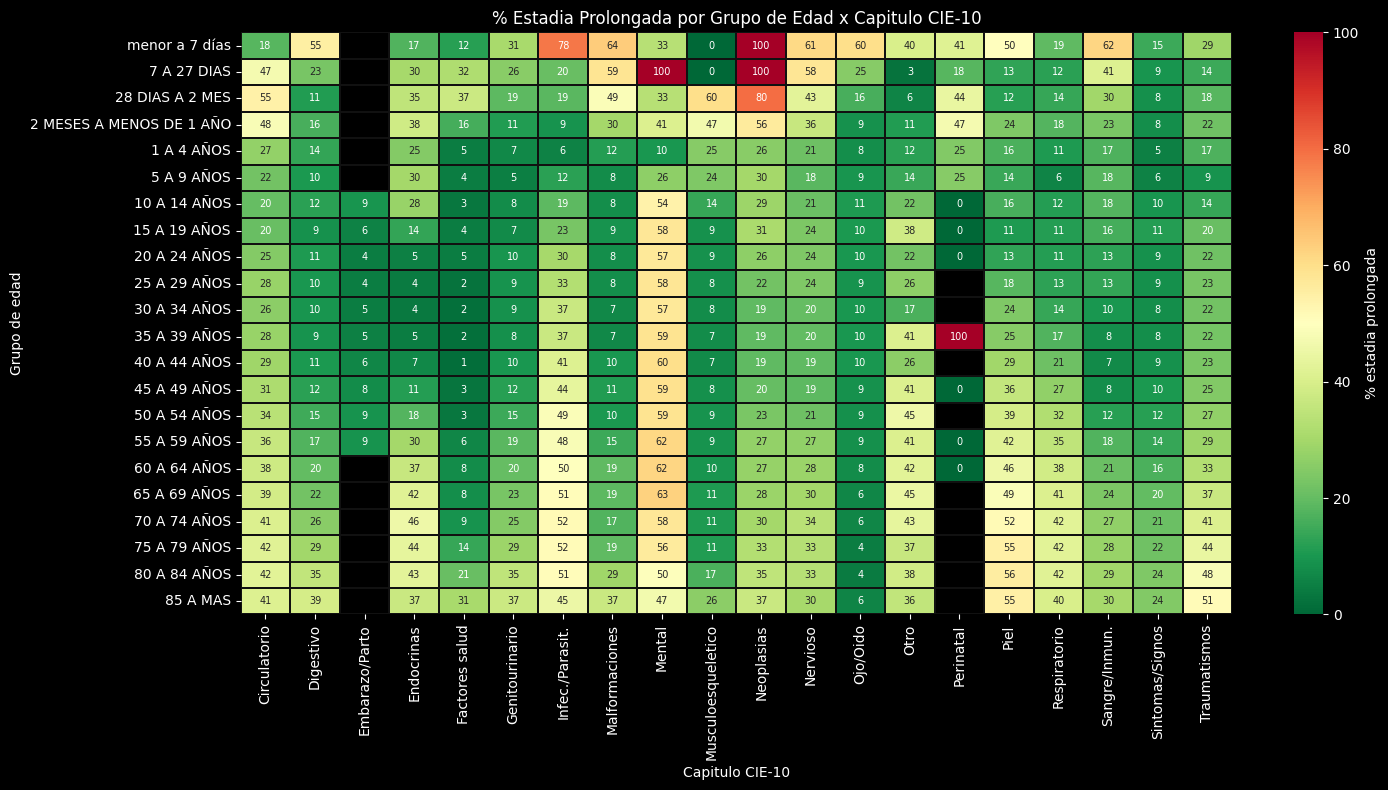

In [25]:
# 5.6 Heatmap: Edad x Capitulo CIE-10
pivot = (
    df.groupby(['GRUPO_EDAD','capitulo_cie10'], observed=True)['estadia_prolongada']
    .mean().unstack() * 100
)
pivot = pivot.dropna(thresh=8, axis=1)

fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.3, linecolor='#111',
            cbar_kws={'label': '% estadia prolongada'},
            annot_kws={'size': 7})
ax.set_title('% Estadia Prolongada por Grupo de Edad x Capitulo CIE-10', fontsize=12)
ax.set_xlabel('Capitulo CIE-10')
ax.set_ylabel('Grupo de edad')
plt.tight_layout()
plt.savefig('fig9_heatmap.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

      PREVISION  pct_prol  mediana       n
      CAPREDENA     25.27      2.0   16246
         FONASA     24.51      3.0 1250994
           SISA     23.59      2.0   11064
        DIPRECA     20.76      2.0   22654
    Desconocida     17.05      2.0   19418
     Particular     15.56      2.0   17505
No identificado     14.42      2.0   28382
         ISAPRE      9.14      1.0  301086


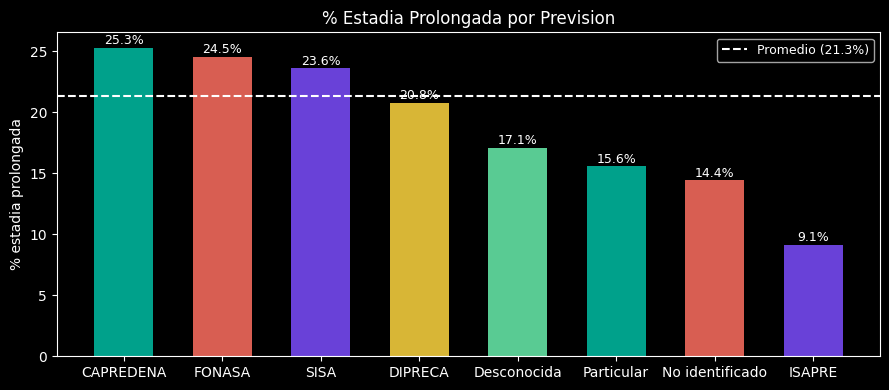

In [26]:
# 5.7 Estadia por Prevision
prev_stats = (
    df.groupby('PREVISION', observed=True)
    .agg(pct_prol=('estadia_prolongada','mean'), mediana=('DIAS_ESTADA','median'), n=('DIAS_ESTADA','count'))
    .reset_index()
)
prev_stats['pct_prol'] *= 100
prev_stats = prev_stats[prev_stats['n'] >= 100].sort_values('pct_prol', ascending=False)
print(prev_stats.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(prev_stats['PREVISION'].astype(str), prev_stats['pct_prol'],
              color=PAL[:len(prev_stats)], alpha=0.85, width=0.6)
ax.axhline(media_global, color='white', lw=1.5, ls='--', label=f'Promedio ({media_global:.1f}%)')
for bar, val in zip(bars, prev_stats['pct_prol']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=9)
ax.set_ylabel('% estadia prolongada'); ax.set_title('% Estadia Prolongada por Prevision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig10_prevision.png', dpi=130, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

In [27]:
# 5.8 Resumen cuantitativo
rango_edad = edad_stats['pct_prol'].max() - edad_stats['pct_prol'].min()
rango_reg  = reg_stats['pct_prol'].max()  - reg_stats['pct_prol'].min()
rango_cap  = cap_stats['pct_prol'].max()  - cap_stats['pct_prol'].min()
rango_prev = prev_stats['pct_prol'].max() - prev_stats['pct_prol'].min()

print('=== RANGO DE VARIACION EN % ESTADIA PROLONGADA ===')
print(f'  Grupo de edad:   {rango_edad:.1f} pp')
print(f'  Region:          {rango_reg:.1f} pp')
print(f'  Capitulo CIE-10: {rango_cap:.1f} pp  <- mayor variacion')
print(f'  Prevision:       {rango_prev:.1f} pp')
print()
print('Correlacion Spearman con estadia_prolongada:')
print(corr_sp['Est. prolongada'].drop('Est. prolongada').sort_values(ascending=False).round(4))
print()
print('-> El diagnostico (CIE-10) y la edad son los predictores mas fuertes individualmente.')
print('-> El heatmap muestra interacciones: adultos mayores con diagnosticos mentales/')
print('   neurologicos concentran el mayor riesgo de estadia prolongada.')

=== RANGO DE VARIACION EN % ESTADIA PROLONGADA ===
  Grupo de edad:   31.7 pp
  Region:          16.0 pp
  Capitulo CIE-10: 52.6 pp  <- mayor variacion
  Prevision:       16.1 pp

Correlacion Spearman con estadia_prolongada:
Dias estadia    0.7264
Edad            0.1871
Cond. egreso    0.1051
Sexo           -0.0908
Prevision      -0.1242
Name: Est. prolongada, dtype: float64

-> El diagnostico (CIE-10) y la edad son los predictores mas fuertes individualmente.
-> El heatmap muestra interacciones: adultos mayores con diagnosticos mentales/
   neurologicos concentran el mayor riesgo de estadia prolongada.


**Respuestas:**
- La mayor correlación Spearman con `estadia_prolongada` la tiene la **edad ordinal** seguida de la **condición de egreso**.
- El **capítulo CIE-10** presenta el mayor rango de variación entre grupos (> 40 pp), superando a edad, región y previsión.
- El heatmap edad × CIE-10 revela interacciones clave: adultos mayores con diagnósticos mentales (F) o neurológicos (G) acumulan el mayor riesgo combinado.
- **Conclusión para el modelado:** el diagnóstico y la edad son los predictores individuales más fuertes, pero su interacción justifica combinar ambos grupos en el modelo final.